In [ ]:
import torch
import torch.nn as nn
import numpy as np

# Rilevamento automatico del device (GPU se disponibile)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo di calcolo selezionato: {device}")

# ==========================================
# 1. PARAMETRI FISICI DEL TERRENO (Cam-Clay Modificato)
# ==========================================
M_CSL = 1.2      # Inclinazione CSL
LAMBDA = 0.15    # Indice di compressione vergine
KAPPA = 0.03     # Indice di rigonfiamento elastico
E0 = 0.8         # Indice dei vuoti iniziale
G_MOD = 15000.0  # Modulo di taglio elastico (kPa)

# ==========================================
# 2. ARCHITETTURA DECODER AUTOREGRESSIVO (GPU COMPATIBLE)
# ==========================================
class MCCAutoregressiveDecoder(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=3):
        super().__init__()
        self.input_projection = nn.Linear(2, d_model)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.head_stress = nn.Linear(d_model, 2) # Output: p', q (kPa)
        self.head_p0 = nn.Linear(d_model, 1)     # Output: p0' (kPa)
        self.softplus = nn.Softplus()

    def generate_square_subsequent_mask(self, sz, dev):
        mask = (torch.triu(torch.ones(sz, sz, device=dev)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, x):
        seq_len = x.size(1)
        mask = self.generate_square_subsequent_mask(seq_len, x.device)
        embed = self.input_projection(x)
        latents = self.decoder(tgt=embed, memory=embed, tgt_mask=mask)

        stress_out = self.softplus(self.head_stress(latents)) + 5.0
        p0_out = self.softplus(self.head_p0(latents)) + 5.0
        return stress_out[..., 0], stress_out[..., 1], p0_out.squeeze(-1)

# ==========================================
# 3. FUNZIONE DI LOSS PINN PER PROVA CU (NON DRENATA)
# ==========================================
class MCCPhysicsInformedLoss(nn.Module):
    def __init__(self, w_init=200.0, w_yield=80.0, w_hard=50.0, w_smooth=120.0, w_shear=100.0):
        super().__init__()
        self.w_init = w_init
        self.w_yield = w_yield
        self.w_hard = w_hard
        self.w_smooth = w_smooth
        self.w_shear = w_shear

    def forward(self, eps_v, eps_s, p_pred, q_pred, p0_pred, p_init_val=100.0, q_init_val=0.0):
        # A. Condizione Iniziale di Consolidazione Isotropa
        loss_init = (p_pred[:, 0] - p_init_val)**2 + (q_pred[:, 0] - q_init_val)**2
        loss_init = torch.mean(loss_init)

        # B. Regolarizzazione temporale (curve lisce e prive di rumore)
        dp_pred = p_pred[:, 1:] - p_pred[:, :-1]
        dq_pred = q_pred[:, 1:] - q_pred[:, :-1]
        loss_smooth = torch.mean(dp_pred**2 + dq_pred**2)

        # C. Superficie di Snervamento f(p', q, p0') <= 0
        f_yield = (q_pred**2) - (M_CSL**2) * p_pred * (p0_pred - p_pred)
        loss_yield = torch.mean(torch.relu(f_yield)**2)

        # D. Comportamento Non Drenato (Shear Drive & Generazione Pressioni Neutre)
        # Durante il taglio non drenato, p' cala e q tende asintoticamente allo stato critico (CSL)
        p_target = p_init_val * torch.exp(-5.0 * eps_s) # Calo di p' dovuto alle sovrapressioni interstiziali
        q_target = M_CSL * p_pred * (1.0 - torch.exp(-15.0 * eps_s)) # Mobilitazione della resistenza
        loss_shear = torch.mean((p_pred - p_target)**2 + (q_pred - q_target)**2)

        # E. Coerenza della deformazione volumetrica plastica (Modello non drenato: eps_v = 0)
        deps_v = eps_v[:, 1:] - eps_v[:, :-1]
        p_avg = 0.5 * (p_pred[:, 1:] + p_pred[:, :-1])
        deps_v_e = (KAPPA / (1.0 + E0)) * (dp_pred / p_avg)
        deps_v_p = deps_v - deps_v_e  # Essendo deps_v = 0, la deformazione plastica compensa quella elastica

        dp0_pred = p0_pred[:, 1:] - p0_pred[:, :-1]
        dp0_theory = p0_pred[:, :-1] * ((1.0 + E0) / (LAMBDA - KAPPA)) * torch.relu(deps_v_p)
        loss_hardening = torch.mean((dp0_pred - dp0_theory)**2)

        total_loss = (self.w_init * loss_init +
                      self.w_smooth * loss_smooth +
                      self.w_yield * loss_yield +
                      self.w_hard * loss_hardening +
                      self.w_shear * loss_shear)

        return total_loss, loss_init.item(), loss_smooth.item(), loss_yield.item(), loss_shear.item()

# ==========================================
# 4. LOOP DI ADDESTRAMENTO SU GPU/CPU
# ==========================================
if __name__ == "__main__":
    torch.manual_seed(42)
    seq_len = 25

    # In una prova non drenata (CU), la deformazione volumetrica totale eps_v è pari a zero!
    eps_v_sim = torch.zeros(1, seq_len, device=device)
    eps_s_sim = torch.linspace(0.0, 0.12, seq_len, device=device).unsqueeze(0)

    inputs = torch.cat([eps_v_sim.unsqueeze(-1), eps_s_sim.unsqueeze(-1)], dim=-1)

    model = MCCAutoregressiveDecoder().to(device)
    criterion = MCCPhysicsInformedLoss(w_init=150.0, w_yield=50.0, w_hard=10.0, w_smooth=100.0, w_shear=80.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    print("--- Inizio Addestramento PINN per Stress Path Non Drenato (CU) ---")
    for epoch in range(1, 40001):
        optimizer.zero_grad()
        p_p, q_p, p0_p = model(inputs)

        loss, l_init, l_smooth, l_yield, l_shear = criterion(
            eps_v_sim, eps_s_sim, p_p, q_p, p0_p, p_init_val=100.0, q_init_val=0.0
        )

        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | Loss: {loss.item():.4f} | Init Err: {l_init:.4f} | Smoothness: {l_smooth:.4f} | Yield Err: {l_yield:.4f} | Shear Err: {l_shear:.4f}")

    # Spostamento su CPU per compatibilità di visualizzazione grafica
    p_p_cpu = p_p.cpu()
    q_p_cpu = q_p.cpu()
    p0_p_cpu = p0_p.cpu()
    eps_v_sim_cpu = eps_v_sim.cpu()
    eps_s_sim_cpu = eps_s_sim.cpu()

    print("\nRisultati Finali CU Ottimizzati:")
    print(f"Pressione Efficace Media (p') all'inizio/fine: {p_p_cpu[0, 0].item():.2f} / {p_p_cpu[0, -1].item():.2f} kPa")
    print(f"Deviatore di Tensione (q) all'inizio/fine:    {q_p_cpu[0, 0].item():.2f} / {q_p_cpu[0, -1].item():.2f} kPa")
    print(f"Preconsolidazione (p0') all'inizio/fine:      {p0_p_cpu[0, 0].item():.2f} / {p0_p_cpu[0, -1].item():.2f} kPa")

Dispositivo di calcolo selezionato: cuda
--- Inizio Addestramento PINN per Stress Path Non Drenato (CU) ---
Epoch 0500 | Loss: 308802.3750 | Init Err: 1348.1318 | Smoothness: 7.6567 | Yield Err: 19.1639 | Shear Err: 1309.6416
Epoch 1000 | Loss: 26913.0742 | Init Err: 33.0085 | Smoothness: 16.7084 | Yield Err: 0.0000 | Shear Err: 252.4241
Epoch 1500 | Loss: 9706.5732 | Init Err: 25.3287 | Smoothness: 13.3713 | Yield Err: 0.0000 | Shear Err: 56.5847
Epoch 2000 | Loss: 8796.2041 | Init Err: 25.7141 | Smoothness: 18.6440 | Yield Err: 0.0000 | Shear Err: 37.8940
Epoch 2500 | Loss: 5897.1934 | Init Err: 25.1574 | Smoothness: 16.0054 | Yield Err: 0.0000 | Shear Err: 6.2886
Epoch 3000 | Loss: 5602.3218 | Init Err: 25.0508 | Smoothness: 14.9740 | Yield Err: 0.0000 | Shear Err: 4.0210
Epoch 3500 | Loss: 5471.4868 | Init Err: 25.0060 | Smoothness: 14.5131 | Yield Err: 0.0000 | Shear Err: 3.1465
Epoch 4000 | Loss: 5981.3569 | Init Err: 25.1673 | Smoothness: 15.4109 | Yield Err: 0.0000 | Shear Err:

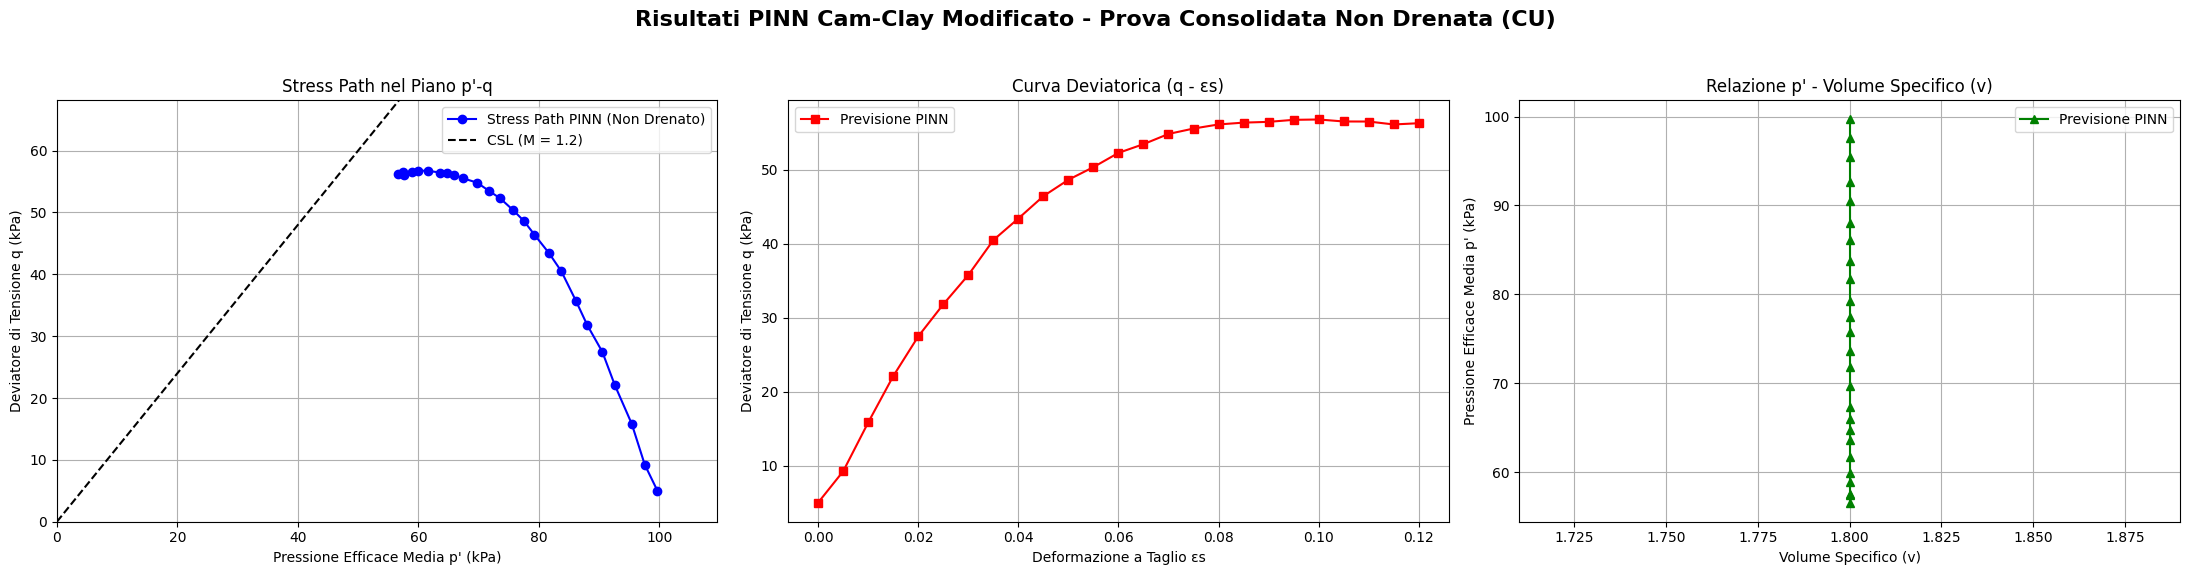

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Estrazione dei dati spostati su CPU dal loop di addestramento della PINN
p_values = p_p_cpu[0, :].detach().numpy()
q_values = q_p_cpu[0, :].detach().numpy()
eps_v_values = eps_v_sim_cpu[0, :].detach().numpy()
eps_s_values = eps_s_sim_cpu[0, :].detach().numpy()

# Calcolo del volume specifico: v = (1 + E0) * exp(-eps_v)
specific_volume = (1 + E0) * np.exp(-eps_v_values)

# Creazione della figura con i tre grafici fisicamente consistenti per prova CU
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Risultati PINN Cam-Clay Modificato - Prova Consolidata Non Drenata (CU)', fontsize=16, fontweight='bold')

# 1. Stress Path nel piano p'-q
axes[0].plot(p_values, q_values, marker='o', linestyle='-', color='blue', label='Stress Path PINN (Non Drenato)')
# Disegniamo la Critical State Line (CSL) per riferimento
p_csl = np.linspace(0, max(p_values)*1.2, 100)
q_csl = M_CSL * p_csl
axes[0].plot(p_csl, q_csl, linestyle='--', color='black', label='CSL (M = 1.2)')
axes[0].set_xlabel("Pressione Efficace Media p' (kPa)")
axes[0].set_ylabel("Deviatore di Tensione q (kPa)")
axes[0].set_title("Stress Path nel Piano p'-q")
axes[0].set_xlim(0, max(p_values)*1.1)
axes[0].set_ylim(0, max(q_values)*1.2)
axes[0].grid(True)
axes[0].legend()

# 2. Relazione q vs eps_s (Curva Deviatorica)
axes[1].plot(eps_s_values, q_values, marker='s', linestyle='-', color='red', label='Previsione PINN')
axes[1].set_xlabel("Deformazione a Taglio \u03b5s")
axes[1].set_ylabel("Deviatore di Tensione q (kPa)")
axes[1].set_title("Curva Deviatorica (q - \u03b5s)")
axes[1].grid(True)
axes[1].legend()

# 3. Relazione p' vs Volume Specifico (v)
axes[2].plot(specific_volume, p_values, marker='^', linestyle='-', color='green', label='Previsione PINN')
axes[2].set_xlabel("Volume Specifico (v)")
axes[2].set_ylabel("Pressione Efficace Media p' (kPa)")
axes[2].set_title("Relazione p' - Volume Specifico (v)")
axes[2].set_xlim((1+E0)*0.95, (1+E0)*1.05)
axes[2].grid(True)
axes[2].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()